# Zomato Data Analytisis Project

## Step 1 - Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 - Create the data frame

In [9]:
dataframe = pd.read_csv("Zomato_data.csv")
print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [10]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


# Convert the data type of column - rate

In [11]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0];
    return float(value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [12]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## Q1. What type of restaurant do the majority of customers order from

In [13]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'type of resturant')

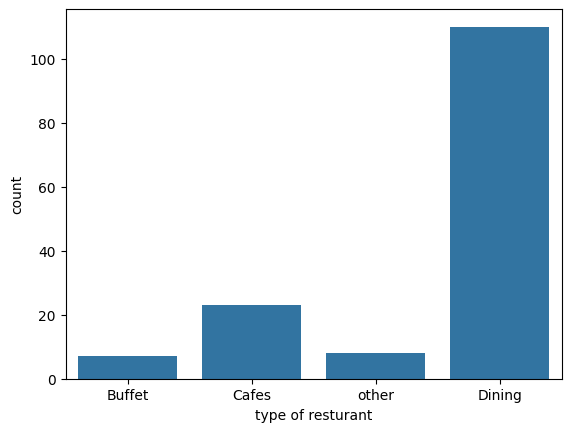

In [14]:
sns.countplot(x = dataframe['listed_in(type)'])
plt.xlabel("type of resturant")

### Conclusion - majority of resturant falls in dinning category  

## Q2. How many votes has each type of restaurant received from customers?

In [15]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0, 0.5, 'Votes')

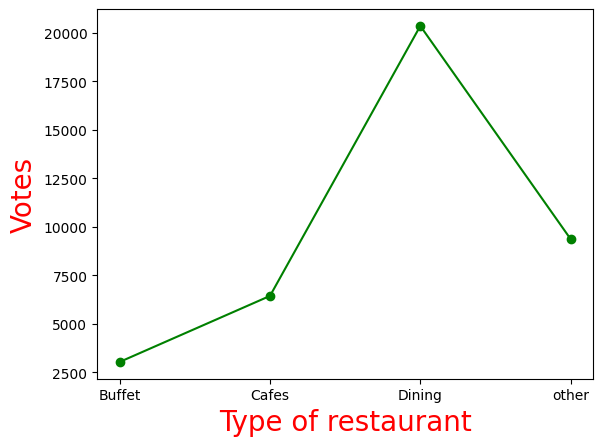

In [16]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c="green", marker="o")
plt.xlabel("Type of restaurant", c="red", size=20)
plt.ylabel("Votes", c="red", size=20)

### Conclusion - Max votes is for Dining

## Q3. What are the ratings that the majority of the restaurants have received?

In [17]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


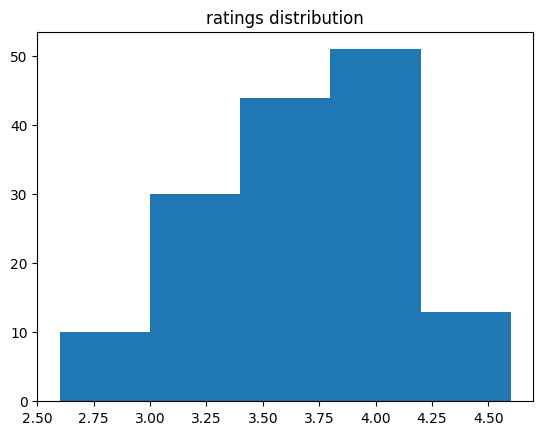

In [18]:
plt.hist(dataframe['rate'],bins = 5)
plt.title("ratings distribution")
plt.show()

### Conclusion - The majority resturants received ratings from 3.5 to 4

## Q4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

In [19]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

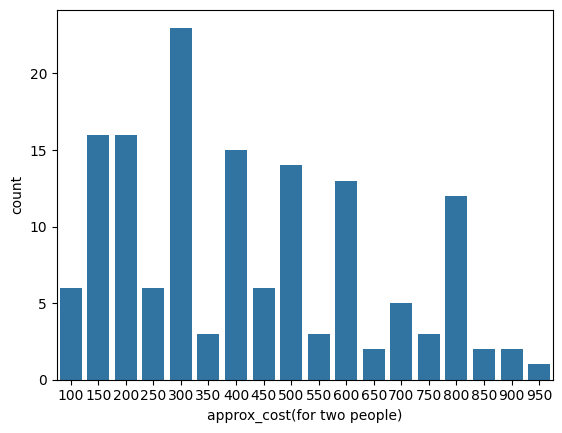

In [20]:
couple_data = dataframe['approx_cost(for two people)']
sns.countplot(x = couple_data)

### Conclusion - The majority of couples prefer restaurants with an approximate cost of 300 rs

## Q5. Which mode (online or offline) has received the maximum rating?

In [21]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='online_order', ylabel='rate'>

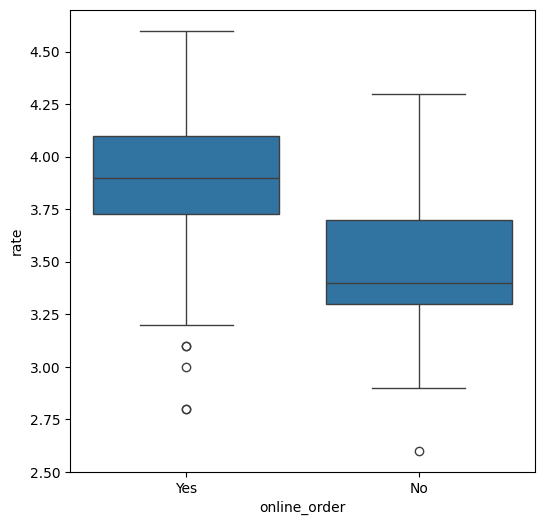

In [22]:
plt.figure(figsize = (6,6))
sns.boxplot(x='online_order', y='rate', data=dataframe)

### Conclusion - Offline order received lower rating in comparison to online order 

## Q6. Which type of restaurant received more offline orders, so that zomato can provide customers with some good offers?

In [23]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


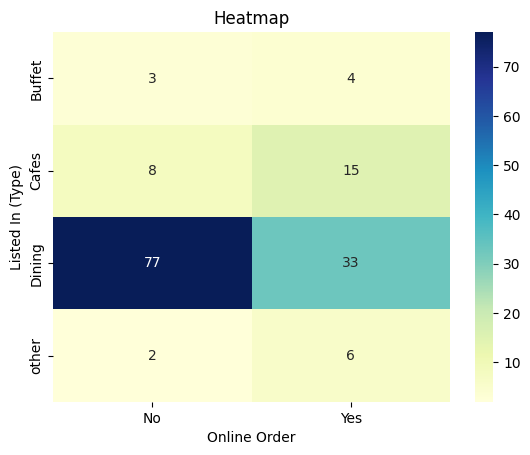

In [24]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()

### Conclusion - Dining restaurants primarily accept offline orders, whereas cafes primarily receive online orders. This suggests that clients prefer orders in person at restaurants, but prefer online ordering at cafes.

In [25]:
dataframe.to_csv("zomato_cleaned.csv", index=False)

In [26]:
%whos

Variable       Type         Data/Info
-------------------------------------
couple_data    Series       0      800\n1      800\n2<...>Length: 148, dtype: int64
dataframe      DataFrame                          nam<...>n\n[148 rows x 7 columns]
grouped_data   Series       listed_in(type)\nBuffet  <...>Name: votes, dtype: int64
handleRate     function     <function handleRate at 0x00000205B7001440>
np             module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd             module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
pivot_table    DataFrame    online_order     No  Yes\<...>nother             2    6
plt            module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
result         DataFrame                     votes\nl<...>3\nother             9367
sns            module       <module 'seaborn' from 'C<...>s\\seaborn\\__init__.py'>


In [27]:
dataframe.to_csv("Zomato_cleaned.csv", index=False)

In [28]:
import os
os.getcwd()

'C:\\Users\\swati\\tanvi'

In [29]:
import os
os.listdir()

['.ipynb_checkpoints',
 'ANNOTATORS',
 'dbcal',
 'desktop.ini',
 'eeg_env',
 'README.st',
 'RECORDS',
 'SHA256SUMS.txt',
 'slp01a.dat',
 'slp01a.ecg',
 'slp01a.hea',
 'slp01a.st',
 'slp01a.st-',
 'slp01a.xws',
 'slp01b.dat',
 'slp01b.ecg',
 'slp01b.hea',
 'slp01b.st',
 'slp01b.st-',
 'slp01b.xws',
 'slp02a.dat',
 'slp02a.ecg',
 'slp02a.hea',
 'slp02a.st',
 'slp02a.st-',
 'slp02a.xws',
 'slp02b.dat',
 'slp02b.ecg',
 'slp02b.hea',
 'slp02b.st',
 'slp02b.st-',
 'slp02b.xws',
 'slp03.dat',
 'slp03.ecg',
 'slp03.hea',
 'slp03.st',
 'slp03.st-',
 'slp03.xws',
 'slp04.dat',
 'slp04.ecg',
 'slp04.hea',
 'slp04.st',
 'slp04.st-',
 'slp04.xws',
 'slp14.dat',
 'slp14.ecg',
 'slp14.hea',
 'slp14.st',
 'slp14.st-',
 'slp14.xws',
 'slp16.dat',
 'slp16.ecg',
 'slp16.hea',
 'slp16.st',
 'slp16.st-',
 'slp16.xws',
 'slp32.dat',
 'slp32.ecg',
 'slp32.hea',
 'slp32.st',
 'slp32.st-',
 'slp32.xws',
 'slp37.dat',
 'slp37.ecg',
 'slp37.hea',
 'slp37.hea-',
 'slp37.st',
 'slp37.st-',
 'slp37.xws',
 'slp41.da

In [30]:
dataframe.to_csv("Zomato_cleaned.csv", index=False)